# PCMCI analysis for the controlled multivariate experiment

This notebook analyzes stored PCMCI trajectory ensembles for the three-variable synthetic case. It filters completed and physically admissible trials, compares recovered and prescribed causal mixtures, loads representative ensemble bundles, and prepares the corresponding manuscript and supplementary diagnostics. The synthetic data are regenerated only to provide the known reference fields used in plotting.

In [48]:
# ============================================================
# 0. Imports and paths
# ============================================================
from __future__ import annotations

import os
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib import gridspec

plt.rcParams["figure.dpi"] = 120

GLOBAL_SEED = 11

# Change this to your actual PCMCI/DYNO output directory
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v5")
BUNDLES_DIR = OUTDIR / "bundles"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v5
Exists: True
Bundles dir exists: True


In [49]:
# ============================================================
# 1. IO helpers
# ============================================================
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []

    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                print(f"Warning: could not parse line {i} in {path}")

    return rows


def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def summarize_table(name, df):
    print(f"{name}: shape={df.shape}")
    if len(df) > 0:
        print(f" columns={list(df.columns[:15])}" + (" ..." if len(df.columns) > 15 else ""))


def _maybe_parse_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return None
        try:
            return json.loads(x)
        except Exception:
            try:
                return ast.literal_eval(x)
            except Exception:
                return x
    return x

In [50]:
# ============================================================
# 2. Load generated results
# ============================================================
jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if alphas_csv_final.exists():
    alphas_df = pd.read_csv(alphas_csv_final)
elif alphas_csv_snapshot.exists():
    alphas_df = pd.read_csv(alphas_csv_snapshot)
else:
    alphas_df = pd.DataFrame(load_jsonl(alphas_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("alphas_df", alphas_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

jobs_df: shape=(30, 52)
 columns=['method', 'trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax', 'pc_alpha', 'graph_p_threshold'] ...
alphas_df: shape=(120, 91)
 columns=['method', 'trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax', 'pc_alpha', 'graph_p_threshold'] ...
members_df: shape=(2400, 40)
 columns=['member_id', 'ok', 'error', 'n_steps', 'path_length', 'net_displacement', 'mean_step', 'stagnant_frac', 'first_step_parent', 'end_parent', 'frac_parent1', 'frac_parent2', 'frac_parent3', 'frac_nontrivial', 'any_nontrivial'] ...
n bundle npz files: 120
n bundle json files: 120

run_metadata:
  seed: 11
  methods: ['pcmci', 'dynotears']
  trials_per_method: 30
  n_workers: 120
  ensemble_size: 20
  flush_every: 5
  alpha_mix_grid: [0.2, 0.4, 0.6, 0.8]
  n_

In [51]:
# ============================================================
# 3. Filter to successful PCMCI results
# ============================================================
for dfname, df in [("jobs_df", jobs_df), ("alphas_df", alphas_df), ("members_df", members_df)]:
    if "method" not in df.columns:
        raise ValueError(f"{dfname} has no 'method' column. Check that this is the PCMCI/DYNOTEARS run output.")

jobs_pcmci = jobs_df[jobs_df["method"].astype(str).str.lower() == "pcmci"].copy()
alphas_pcmci = alphas_df[alphas_df["method"].astype(str).str.lower() == "pcmci"].copy()
members_pcmci = members_df[members_df["method"].astype(str).str.lower() == "pcmci"].copy()

if "ok" in jobs_pcmci.columns:
    jobs_pcmci = jobs_pcmci[jobs_pcmci["ok"] == 1].copy()

if "ok" in members_pcmci.columns:
    members_pcmci["ok"] = pd.to_numeric(members_pcmci["ok"], errors="coerce")

print("PCMCI jobs:", jobs_pcmci.shape)
print("PCMCI alpha rows:", alphas_pcmci.shape)
print("PCMCI member rows:", members_pcmci.shape)

print("\nPCMCI trials:", jobs_pcmci["trial_id"].nunique() if "trial_id" in jobs_pcmci else "NA")
print("PCMCI alpha values:", sorted(pd.to_numeric(alphas_pcmci["alpha_mix"], errors="coerce").dropna().unique()))

if len(jobs_pcmci) > 0:
    display(jobs_pcmci.head())

PCMCI jobs: (30, 52)
PCMCI alpha rows: (120, 91)
PCMCI member rows: (2400, 40)

PCMCI trials: 30
PCMCI alpha values: [0.2, 0.4, 0.6, 0.8]


,method,trial_id,timewindow,box_size,radius,eps_dbscan,min_samples_dbscan,score_mode,winner_summary,alpha,...,corr_alpha_vs_initial_var1,corr_prescribed_vs_estimated_alpha_end,corr_prescribed_vs_estimated_alpha_density,slope_prescribed_vs_estimated_alpha_end,slope_prescribed_vs_estimated_alpha_density,intercept_prescribed_vs_estimated_alpha_end,intercept_prescribed_vs_estimated_alpha_density,elapsed_sec,ok,error
0,pcmci,19,6d,35,4,0.05,2,mean,mean,4.0,...,-0.325065,-0.948683,0.669038,-0.150,0.082166,0.425,0.278809,3389.385846,1,NaN
1,pcmci,20,5d,30,5,0.05,2,sum,mean,4.0,...,-0.727961,0.989949,0.914814,0.350,0.070499,0.125,0.296963,3447.552626,1,NaN
2,pcmci,8,5d,30,4,0.25,2,mean,mean,4.0,...,-0.943880,0.613795,0.028440,0.225,0.001650,0.225,0.324014,4209.894273,1,NaN
3,pcmci,0,5d,30,6,0.15,2,sum,mean,8.0,...,-0.547723,-0.707107,-0.328058,-0.250,-0.029257,0.575,0.378619,4253.381867,1,NaN
4,pcmci,29,7d,40,4,0.20,2,sum,mean,64.0,...,-0.187867,0.316228,-0.265488,0.050,-0.019308,0.275,0.311492,4323.983046,1,NaN


In [52]:
# ============================================================
# 4. Numeric cleaning and useful summary
# ============================================================
numeric_cols_jobs = [
    "frac_alpha_valid_physical",
    "mean_mae_density",
    "mean_mae_end",
    "mean_mae_step",
    "mean_ok_frac",
    "min_ok_frac",
    "mean_density_var2_frac",
    "mean_step_var2_frac",
    "corr_prescribed_vs_estimated_alpha_density",
    "corr_prescribed_vs_estimated_alpha_end",
    "slope_prescribed_vs_estimated_alpha_density",
    "slope_prescribed_vs_estimated_alpha_end",
]

numeric_cols_alphas = [
    "alpha_mix",
    "target_var1",
    "target_var3",
    "estimated_alpha_density",
    "estimated_alpha_end",
    "mae_density",
    "mae_end",
    "density_frac_var1",
    "density_frac_var2",
    "density_frac_var3",
    "end_frac_var1",
    "end_frac_var2",
    "end_frac_var3",
    "step_frac_var1",
    "step_frac_var2",
    "step_frac_var3",
    "ok_frac",
    "mean_n_steps",
    "mean_net_displacement",
    "mean_stagnant_frac",
]

for c in numeric_cols_jobs:
    if c in jobs_pcmci.columns:
        jobs_pcmci[c] = pd.to_numeric(jobs_pcmci[c], errors="coerce")

for c in numeric_cols_alphas:
    if c in alphas_pcmci.columns:
        alphas_pcmci[c] = pd.to_numeric(alphas_pcmci[c], errors="coerce")

print("PCMCI job-level summary:")
display(
    jobs_pcmci[
        [c for c in [
            "trial_id",
            "frac_alpha_valid_physical",
            "mean_mae_density",
            "mean_mae_end",
            "mean_density_var2_frac",
            "corr_prescribed_vs_estimated_alpha_density",
            "slope_prescribed_vs_estimated_alpha_density",
            "elapsed_sec",
        ] if c in jobs_pcmci.columns]
    ].describe()
)

print("\nPCMCI alpha-level summary by alpha_mix:")
display(
    alphas_pcmci.groupby("alpha_mix")[
        [c for c in [
            "estimated_alpha_density",
            "estimated_alpha_end",
            "mae_density",
            "mae_end",
            "density_frac_var2",
            "ok_frac",
            "mean_net_displacement",
            "mean_stagnant_frac",
        ] if c in alphas_pcmci.columns]
    ].agg(["mean", "median", "std", "min", "max"])
)

PCMCI job-level summary:


,trial_id,frac_alpha_valid_physical,mean_mae_density,mean_mae_end,mean_density_var2_frac,corr_prescribed_vs_estimated_alpha_density,slope_prescribed_vs_estimated_alpha_density,elapsed_sec
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,14.500000,0.975000,0.233834,0.233542,0.345928,0.270671,0.023567,9560.569741
std,8.803408,0.076282,0.007905,0.031889,0.017453,0.403307,0.038885,6946.101237
min,0.000000,0.750000,0.219512,0.162500,0.321507,-0.527153,-0.062579,3389.385846
25%,7.250000,1.000000,0.228978,0.218750,0.329741,-0.017581,-0.001432,5586.101815
50%,14.500000,1.000000,0.233702,0.237500,0.345031,0.293513,0.026769,6844.180230
75%,21.750000,1.000000,0.237796,0.250000,0.359130,0.544627,0.051079,12180.132233
max,29.000000,1.000000,0.251485,0.312500,0.380752,0.914814,0.085219,33483.165845



PCMCI alpha-level summary by alpha_mix:


estimated_alpha_density                                          \
                             mean    median       std       min       max   
alpha_mix                                                                   
0.2                      0.314095  0.317814  0.028206  0.268451  0.383836   
0.4                      0.318980  0.315958  0.032922  0.249482  0.400908   
0.6                      0.324468  0.325232  0.027292  0.273689  0.380324   
0.8                      0.327977  0.328619  0.028713  0.270132  0.376557   

          estimated_alpha_end                              ...  \
                         mean median       std   min  max  ...   
alpha_mix                                                  ...   
0.2                  0.306667   0.30  0.121580  0.05  0.6  ...   
0.4                  0.338333   0.35  0.096207  0.10  0.5  ...   
0.6                  0.330000   0.30  0.111107  0.15  0.6  ...   
0.8                  0.358333   0.35  0.086187  0.20  0.5  ...   

          mean_net_displacement                                             \
                           mean     median       std        min        max   
alpha_mix                                                                    
0.2                   20.954489  20.301900  4.207357  13.247515  27.973467   
0.4                   21.633544  21.868620  4.077772  14.401695  30.956801   
0.6                   20.671641  20.305424  3.809770  13.970679  26.832552   
0.8                   21.484872  22.038725  4.422774  13.731709  29.223473   

          mean_stagnant_frac                                          
                        mean    median       std       min       max  
alpha_mix                                                             
0.2                 0.144259  0.115833  0.110653  0.016667  0.415000  
0.4                 0.144444  0.115000  0.105003  0.020000  0.386667  
0.6                 0.142667  0.119167  0.107654  0.011667  0.400000  
0.8                 0.147861  0.117500  0.112487  0.013333  0.386667  

[4 rows x 40 columns]

In [53]:
# ============================================================
# 5. Select best/relevant PCMCI trials
# ============================================================
# Primary ranking:
# 1. Prefer physically valid alpha cases.
# 2. Minimize density-based alpha recovery error.
# 3. Minimize step-based error.
# 4. Penalize high Var. 2 / self-attribution.

rank_cols = [
    c for c in [
        "frac_alpha_valid_physical",
        "mean_mae_density",
        "mean_mae_step",
        "mean_density_var2_frac",
    ]
    if c in jobs_pcmci.columns
]

ascending = []
for c in rank_cols:
    if c == "frac_alpha_valid_physical":
        ascending.append(False)
    else:
        ascending.append(True)

jobs_pcmci_ranked = jobs_pcmci.sort_values(rank_cols, ascending=ascending).reset_index(drop=True)

print("Best PCMCI jobs:")
display(
    jobs_pcmci_ranked[
        [c for c in [
            "method",
            "trial_id",
            "frac_alpha_valid_physical",
            "mean_mae_density",
            "mean_mae_end",
            "mean_mae_step",
            "mean_density_var2_frac",
            "mean_step_var2_frac",
            "corr_prescribed_vs_estimated_alpha_density",
            "slope_prescribed_vs_estimated_alpha_density",
            "timewindow",
            "box_size",
            "radius",
            "pc_alpha",
            "graph_p_threshold",
            "cond_ind_test_name",
            "fdr_method",
        ] if c in jobs_pcmci_ranked.columns]
    ].head(10)
)

best_pcmci_job = jobs_pcmci_ranked.iloc[0].copy()
best_pcmci_trial_id = int(best_pcmci_job["trial_id"])

print("Selected best PCMCI trial:", best_pcmci_trial_id)

Best PCMCI jobs:


,method,trial_id,frac_alpha_valid_physical,mean_mae_density,mean_mae_end,mean_mae_step,mean_density_var2_frac,mean_step_var2_frac,corr_prescribed_vs_estimated_alpha_density,slope_prescribed_vs_estimated_alpha_density,timewindow,box_size,radius,pc_alpha,graph_p_threshold,cond_ind_test_name,fdr_method
0,pcmci,19,1.0,0.219512,0.24375,0.219355,0.321507,0.320968,0.669038,0.082166,6d,35,4,0.0001,0.0100,parcorr,NaN
1,pcmci,21,1.0,0.221512,0.23750,0.221371,0.323920,0.323387,0.496116,0.035439,5d,35,4,0.0001,0.1000,robustparcorr,NaN
2,pcmci,3,1.0,0.222530,0.17500,0.222177,0.323145,0.321774,0.532232,0.019312,7d,40,6,0.0010,0.0100,robustparcorr,NaN
3,pcmci,5,1.0,0.223671,0.23125,0.223589,0.365322,0.364919,0.478608,0.054827,7d,35,6,0.0010,0.0010,parcorr,NaN
4,pcmci,9,1.0,0.224238,0.24375,0.223992,0.326816,0.325403,-0.022954,-0.002756,5d,40,4,0.0010,0.0001,robustparcorr,NaN
5,pcmci,20,1.0,0.224547,0.21875,0.223992,0.330486,0.328629,0.914814,0.070499,5d,30,5,0.0001,0.0010,parcorr,bh
6,pcmci,12,1.0,0.227516,0.24375,0.227016,0.358212,0.356452,0.822976,0.051403,7d,30,6,0.0100,0.0010,parcorr,bh
7,pcmci,4,1.0,0.228779,0.23750,0.228629,0.337602,0.337097,-0.020212,-0.001733,7d,35,6,0.1000,0.1000,robustparcorr,NaN
8,pcmci,2,1.0,0.229576,0.16250,0.229435,0.323926,0.323387,0.157749,0.018546,6d,35,6,0.0001,0.0100,parcorr,bh
9,pcmci,23,1.0,0.230096,0.21875,0.229637,0.343983,0.342339,0.299231,0.029310,7d,40,6,0.1000,0.0001,parcorr,bh


Selected best PCMCI trial: 19


In [54]:
# ============================================================
# 6. Bundle loader for method-aware filenames
# ============================================================
def bundle_stem_multivar_method(method, trial_id, alpha_mix):
    alpha_tag = str(float(alpha_mix)).replace(".", "p")
    return f"{str(method).lower()}_trial_{int(trial_id):05d}_alpha_{alpha_tag}"


def load_multivar_bundle_method(method, trial_id, alpha_mix, bundles_dir=BUNDLES_DIR):
    stem = bundle_stem_multivar_method(method, trial_id, alpha_mix)
    npz_path = bundles_dir / f"{stem}.npz"
    json_path = bundles_dir / f"{stem}.json"

    if not npz_path.exists():
        raise FileNotFoundError(f"Missing bundle npz: {npz_path}")
    if not json_path.exists():
        raise FileNotFoundError(f"Missing bundle json: {json_path}")

    arrays_npz = np.load(npz_path, allow_pickle=True)
    arrays = {k: arrays_npz[k] for k in arrays_npz.files}
    meta = load_json(json_path)

    return {
        "arrays": arrays,
        "meta": meta,
        "npz_path": npz_path,
        "json_path": json_path,
    }


# Test-load one bundle for the selected trial and alpha=0.6
alpha_target = 0.6
bundle_test = load_multivar_bundle_method("pcmci", best_pcmci_trial_id, alpha_target)

print("Loaded bundle:")
print(bundle_test["npz_path"])
print(bundle_test["json_path"])
print("Array keys:", bundle_test["arrays"].keys())
print("Meta keys:", bundle_test["meta"].keys())

Loaded bundle:
/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v5/bundles/pcmci_trial_00019_alpha_0p6.npz
/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v5/bundles/pcmci_trial_00019_alpha_0p6.json
Array keys: dict_keys(['centers', 'parents', 'lengths', 'ok', 'elapsed_sec', 'member_id', 'density_parent1', 'density_parent2', 'density_parent3', 'xs', 'ys', 'truth_centers_A', 'truth_centers_C'])
Meta keys: dict_keys(['method', 'trial_id', 'alpha_mix', 'trial', 'params', 'case_meta', 'summary_small', 'errors'])


In [55]:
# ============================================================
# 7. Synthetic-case regeneration helpers for plotting
# ============================================================
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    dy = y2d - float(y0)
    dx = x2d - float(x0)
    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


def bezier_centers(start, control1, control2, end, T):
    u = np.linspace(0.0, 1.0, T)
    centers = np.zeros((T, 2), dtype=float)

    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)

    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )

    return centers


def make_spatiotemporal_ar1_noise(
    shape,
    phi=0.8,
    sigma=0.1,
    smooth_sigma_y=1.5,
    smooth_sigma_x=1.5,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(eps0, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(eps, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
        noise[t] = phi * noise[t - 1] + eps

    return noise


def build_dataarray(var_name, arr, time_coord, ys, xs):
    return xr.DataArray(
        arr[:, None, :, :].astype(np.float32),
        dims=("time", "var", "y", "x"),
        coords={
            "time": time_coord,
            "var": [var_name],
            "y": ys,
            "x": xs,
        },
        name="synthetic",
    )


def build_multivariate_case(
    alpha_mix=0.6,
    T=40,
    N_inject=8,
    tau_mix=1,
    sig_y=10.0,
    sig_x=10.0,
    amp_A=1.0,
    amp_C=1.0,
    phi_A=0.85,
    phi_C=0.85,
    phi_B=0.80,
    sigma_A=0.10,
    sigma_C=0.10,
    sigma_B=0.10,
    clip_to_positive=True,
    seed=GLOBAL_SEED,
):
    time_coord = pd.date_range("2001-01-01", periods=T, freq="D")

    Y_MIN, Y_MAX = 0, 200
    X_MIN, X_MAX = 0, 200
    NY = 121
    NX = 241

    ys = np.linspace(Y_MIN, Y_MAX, NY)
    xs = np.linspace(X_MIN, X_MAX, NX)
    x2d, y2d = np.meshgrid(xs, ys)

    event_y = 100.0
    event_x = 100.0

    centers_A = bezier_centers(
        start=(145.0, 60.0),
        control1=(142.0, 95.0),
        control2=(120.0, 98.0),
        end=(event_y, event_x),
        T=T,
    )

    centers_C = bezier_centers(
        start=(40.0, 150.0),
        control1=(75.0, 148.0),
        control2=(98.0, 118.0),
        end=(event_y, event_x),
        T=T,
    )

    A_clean = np.zeros((T, NY, NX), dtype=np.float32)
    C_clean = np.zeros((T, NY, NX), dtype=np.float32)

    for t in range(T):
        A_clean[t] = gaussian_blob(
            y2d,
            x2d,
            y0=centers_A[t, 0],
            x0=centers_A[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_A,
        ).astype(np.float32)

        C_clean[t] = gaussian_blob(
            y2d,
            x2d,
            y0=centers_C[t, 0],
            x0=centers_C[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_C,
        ).astype(np.float32)

    rng_A = np.random.default_rng(seed + 0)
    rng_C = np.random.default_rng(seed + 2)

    noise_A = make_spatiotemporal_ar1_noise(
        A_clean.shape,
        phi=phi_A,
        sigma=sigma_A,
        rng=rng_A,
    )

    noise_C = make_spatiotemporal_ar1_noise(
        C_clean.shape,
        phi=phi_C,
        sigma=sigma_C,
        rng=rng_C,
    )

    A = A_clean + noise_A
    C = C_clean + noise_C

    if clip_to_positive:
        A = np.clip(A, 0.0, None)
        C = np.clip(C, 0.0, None)

    t0 = T - int(N_inject)
    if t0 < 0:
        raise ValueError("N_inject too large.")
    if t0 - tau_mix < 0:
        raise ValueError("Need t0 - tau_mix >= 0.")

    rng_B = np.random.default_rng(seed + 1)
    noise_B = make_spatiotemporal_ar1_noise(
        (T, NY, NX),
        phi=phi_B,
        sigma=sigma_B,
        rng=rng_B,
    )

    B = noise_B.copy()

    for t in range(t0, T):
        B[t] = (
            alpha_mix * A_clean[t - tau_mix]
            + (1.0 - alpha_mix) * C_clean[t - tau_mix]
            + noise_B[t]
        )

    if clip_to_positive:
        B = np.clip(B, 0.0, None)

    full_data_A = build_dataarray("A", A, time_coord, ys, xs)
    full_data_B = build_dataarray("B", B, time_coord, ys, xs)
    full_data_C = build_dataarray("C", C, time_coord, ys, xs)

    full_data_run = xr.concat([full_data_A, full_data_B, full_data_C], dim="var")
    full_data_run = full_data_run.rename({"y": "lat", "x": "lon"})

    date_end = str(time_coord[-1].date())

    return dict(
        full_data_run=full_data_run,
        A=A,
        B=B,
        C=C,
        A_clean=A_clean,
        C_clean=C_clean,
        centers_A=centers_A,
        centers_C=centers_C,
        event=(event_y, event_x),
        xs=xs,
        ys=ys,
        x2d=x2d,
        y2d=y2d,
        time=time_coord,
        T=T,
        date_end=date_end,
        alpha_mix=float(alpha_mix),
        target_parent_fractions={1: float(alpha_mix), 3: float(1.0 - alpha_mix)},
        injection_start_idx=int(t0),
        tau_mix=int(tau_mix),
        N_inject=int(N_inject),
    )

In [56]:
# ============================================================
# 8. Pick visually appealing PCMCI alpha row and load bundle
#    Priority: valid + complete/non-stagnant tracks first,
#    then good endpoint/source attribution.
# ============================================================
alpha_target = 0.4

alpha_sub_pcmci = alphas_pcmci[
    np.isclose(pd.to_numeric(alphas_pcmci["alpha_mix"], errors="coerce"), alpha_target)
].copy()

# Make sure relevant columns are numeric
for c in [
    "is_valid_physical",
    "mae_end",
    "mae_density",
    "ok_frac",
    "mean_n_steps",
    "q25_n_steps",
    "min_n_steps",
    "mean_net_displacement",
    "mean_path_length",
    "mean_stagnant_frac",
    "frac_members_any_nontrivial",
    "frac_members_end_nontrivial",
    "frac_members_use_both_nontrivial",
    "density_frac_var2",
    "end_frac_var2",
]:
    if c in alpha_sub_pcmci.columns:
        alpha_sub_pcmci[c] = pd.to_numeric(alpha_sub_pcmci[c], errors="coerce")

# Optional: restrict to reasonable candidates first
candidate = alpha_sub_pcmci.copy()

if "is_valid_physical" in candidate.columns:
    candidate = candidate[
        (candidate["is_valid_physical"] == True)
        | (candidate["is_valid_physical"].astype(str).str.lower() == "true")
        | (pd.to_numeric(candidate["is_valid_physical"], errors="coerce") == 1)
    ].copy()

if len(candidate) == 0:
    print("No physically valid candidates found. Falling back to all alpha rows.")
    candidate = alpha_sub_pcmci.copy()

# Visual quality score:
# lower is better.
# This favors complete, moving, non-stagnant, source-attributing tracks,
# while still keeping attribution error low.
candidate["visual_score"] = (
    2.0 * candidate.get("mae_end", 0.0)
    + 1.0 * candidate.get("mae_density", 0.0)
    + 2.0 * candidate.get("mean_stagnant_frac", 0.0)
    + 1.5 * candidate.get("density_frac_var2", 0.0)
    + 1.0 * candidate.get("end_frac_var2", 0.0)
    - 0.03 * candidate.get("mean_net_displacement", 0.0)
    - 0.02 * candidate.get("mean_path_length", 0.0)
    - 1.0 * candidate.get("frac_members_any_nontrivial", 0.0)
    - 1.0 * candidate.get("frac_members_end_nontrivial", 0.0)
    - 0.5 * candidate.get("frac_members_use_both_nontrivial", 0.0)
)

sort_cols = [
    c for c in [
        "visual_score",
        "mean_stagnant_frac",
        "mae_end",
        "mean_net_displacement",
        "mae_density",
        "ok_frac",
    ]
    if c in candidate.columns
]

ascending = []
for c in sort_cols:
    if c in ["mean_net_displacement", "ok_frac"]:
        ascending.append(False)
    else:
        ascending.append(True)

row_pcmci_H = candidate.sort_values(sort_cols, ascending=ascending).iloc[0].copy()

bundle_pcmci_H = load_multivar_bundle_method(
    method="pcmci",
    trial_id=int(row_pcmci_H["trial_id"]),
    alpha_mix=float(row_pcmci_H["alpha_mix"]),
)

display(
    row_pcmci_H[
        [c for c in [
            "method",
            "trial_id",
            "alpha_mix",
            "visual_score",
            "is_valid_physical",
            "mae_end",
            "mae_density",
            "ok_frac",
            "mean_n_steps",
            "mean_net_displacement",
            "mean_path_length",
            "mean_stagnant_frac",
            "frac_members_any_nontrivial",
            "frac_members_end_nontrivial",
            "frac_members_use_both_nontrivial",
            "density_frac_var1",
            "density_frac_var2",
            "density_frac_var3",
            "end_frac_var1",
            "end_frac_var2",
            "end_frac_var3",
        ] if c in row_pcmci_H.index]
    ].to_frame().T
)

print("Representative PCMCI bundle:")
print(bundle_pcmci_H["npz_path"])

,method,trial_id,alpha_mix,visual_score,is_valid_physical,mae_end,mae_density,ok_frac,mean_n_steps,mean_net_displacement,...,mean_stagnant_frac,frac_members_any_nontrivial,frac_members_end_nontrivial,frac_members_use_both_nontrivial,density_frac_var1,density_frac_var2,density_frac_var3,end_frac_var1,end_frac_var2,end_frac_var3
29,pcmci,2,0.4,-4.98052,True,0.05,0.165592,1.0,31.0,24.129664,...,0.045,1.0,0.9,1.0,0.309428,0.331185,0.359388,0.4,0.1,0.5


Representative PCMCI bundle:
/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v5/bundles/pcmci_trial_00002_alpha_0p4.npz


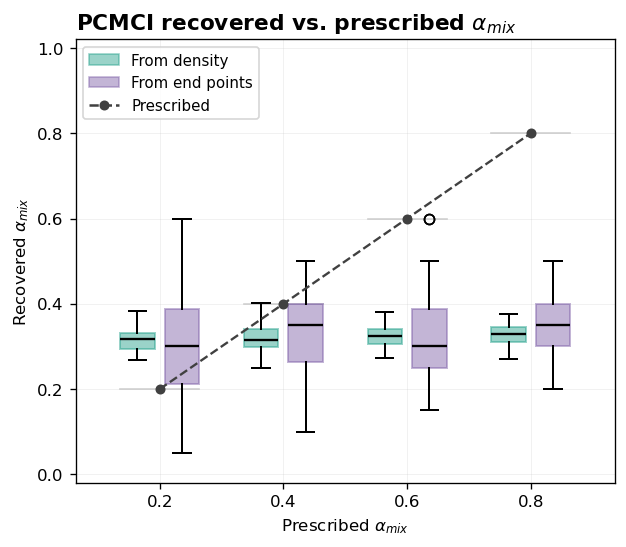

In [58]:
# ============================================================
# 10. Recovered vs prescribed alpha_mix for PCMCI
# ============================================================
def plot_pcmci_alpha_recovery_boxplots(
    ax,
    *,
    alphas_df,
    alpha_grid=(0.2, 0.4, 0.6, 0.8),
    density_col="estimated_alpha_density",
    end_col="estimated_alpha_end",
    title=r"PCMCI recovered vs. prescribed $\alpha_{mix}$",
):
    df = alphas_df.copy()

    df["alpha_mix"] = pd.to_numeric(df["alpha_mix"], errors="coerce")
    df[density_col] = pd.to_numeric(df[density_col], errors="coerce")
    df[end_col] = pd.to_numeric(df[end_col], errors="coerce")

    alpha_grid = [float(a) for a in alpha_grid]

    dens_data = []
    end_data = []
    valid_alpha = []

    for a in alpha_grid:
        sub = df[np.isclose(df["alpha_mix"], a)].copy()

        vals_d = sub[density_col].to_numpy(dtype=float)
        vals_d = vals_d[np.isfinite(vals_d)]

        vals_e = sub[end_col].to_numpy(dtype=float)
        vals_e = vals_e[np.isfinite(vals_e)]

        if (len(vals_d) == 0) and (len(vals_e) == 0):
            continue

        dens_data.append(vals_d if len(vals_d) else np.array([np.nan]))
        end_data.append(vals_e if len(vals_e) else np.array([np.nan]))
        valid_alpha.append(a)

    x = np.arange(len(valid_alpha), dtype=float)
    pos_d = x - 0.18
    pos_e = x + 0.18

    color_density = "#1f9e89"
    color_end = "#7a5ba6"

    bp_d = ax.boxplot(
        dens_data,
        positions=pos_d,
        widths=0.28,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    for patch in bp_d["boxes"]:
        patch.set_facecolor(color_density)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color_density)

    bp_e = ax.boxplot(
        end_data,
        positions=pos_e,
        widths=0.28,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    for patch in bp_e["boxes"]:
        patch.set_facecolor(color_end)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color_end)

    ax.plot(
        x,
        valid_alpha,
        "o--",
        color="0.25",
        linewidth=1.4,
        markersize=5,
        zorder=3,
    )

    for xi, a in zip(x, valid_alpha):
        ax.plot(
            [xi - 0.32, xi + 0.32],
            [a, a],
            color="0.82",
            linewidth=1.0,
            zorder=0,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"{a:.1f}" for a in valid_alpha])
    ax.set_xlabel(r"Prescribed $\alpha_{mix}$")
    ax.set_ylabel(r"Recovered $\alpha_{mix}$")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.20, linewidth=0.5)

    handles = [
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=color_density,
            edgecolor=color_density,
            alpha=0.45,
            label=r"From density",
        ),
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=color_end,
            edgecolor=color_end,
            alpha=0.45,
            label=r"From end points",
        ),
        Line2D(
            [0], [0],
            color="0.25",
            linestyle="--",
            marker="o",
            markersize=5,
            label=r"Prescribed",
        ),
    ]

    ax.legend(handles=handles, frameon=True, fontsize=9, loc="upper left")
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")


fig, ax = plt.subplots(figsize=(5.8, 4.8))
plot_pcmci_alpha_recovery_boxplots(
    ax,
    alphas_df=alphas_pcmci,
    alpha_grid=(0.2, 0.4, 0.6, 0.8),
)
plt.savefig('sup_synth2_pcmci.pdf',bbox_inches='tight')

In [20]:
# ============================================================
# 11. Summary statistics for alpha recovery
# ============================================================
summary_alpha_pcmci = (
    alphas_pcmci
    .groupby("alpha_mix", as_index=False)
    .agg(
        n=("trial_id", "count"),
        mean_est_density=("estimated_alpha_density", "mean"),
        median_est_density=("estimated_alpha_density", "median"),
        std_est_density=("estimated_alpha_density", "std"),
        mean_est_end=("estimated_alpha_end", "mean"),
        median_est_end=("estimated_alpha_end", "median"),
        std_est_end=("estimated_alpha_end", "std"),
        mean_mae_density=("mae_density", "mean"),
        median_mae_density=("mae_density", "median"),
        mean_mae_end=("mae_end", "mean"),
        median_mae_end=("mae_end", "median"),
        mean_density_var2=("density_frac_var2", "mean"),
        median_density_var2=("density_frac_var2", "median"),
        mean_end_var2=("end_frac_var2", "mean"),
        median_end_var2=("end_frac_var2", "median"),
        mean_ok_frac=("ok_frac", "mean"),
        mean_stagnant_frac=("mean_stagnant_frac", "mean"),
    )
)

display(summary_alpha_pcmci)

print("Best job-level PCMCI rows:")
display(
    jobs_pcmci_ranked[
        [c for c in [
            "trial_id",
            "frac_alpha_valid_physical",
            "mean_mae_density",
            "mean_mae_end",
            "mean_density_var2_frac",
            "mean_step_var2_frac",
            "corr_prescribed_vs_estimated_alpha_density",
            "slope_prescribed_vs_estimated_alpha_density",
            "pc_alpha",
            "graph_p_threshold",
            "cond_ind_test_name",
            "fdr_method",
            "timewindow",
            "box_size",
            "radius",
        ] if c in jobs_pcmci_ranked.columns]
    ].head(15)
)

,alpha_mix,n,mean_est_density,median_est_density,std_est_density,mean_est_end,median_est_end,std_est_end,mean_mae_density,median_mae_density,mean_mae_end,median_mae_end,mean_density_var2,median_density_var2,mean_end_var2,median_end_var2,mean_ok_frac,mean_stagnant_frac
0,0.2,30,0.314095,0.317814,0.028206,0.306667,0.30,0.121580,0.289565,0.289523,0.287500,0.2875,0.350940,0.351642,0.341667,0.35,1.0,0.144259
1,0.4,30,0.318980,0.315958,0.032922,0.338333,0.35,0.096207,0.174137,0.173403,0.166667,0.1750,0.348213,0.346805,0.316667,0.35,1.0,0.144444
2,0.6,30,0.324468,0.325232,0.027292,0.330000,0.30,0.111107,0.170945,0.172679,0.186667,0.1750,0.341889,0.345358,0.330000,0.35,1.0,0.142667
3,0.8,30,0.327977,0.328619,0.028713,0.358333,0.35,0.086187,0.300689,0.304048,0.293333,0.3000,0.342669,0.340621,0.306667,0.30,1.0,0.147861


Best job-level PCMCI rows:


,trial_id,frac_alpha_valid_physical,mean_mae_density,mean_mae_end,mean_density_var2_frac,mean_step_var2_frac,corr_prescribed_vs_estimated_alpha_density,slope_prescribed_vs_estimated_alpha_density,pc_alpha,graph_p_threshold,cond_ind_test_name,fdr_method,timewindow,box_size,radius
0,19,1.0,0.219512,0.24375,0.321507,0.320968,0.669038,0.082166,0.0001,0.0100,parcorr,NaN,6d,35,4
1,21,1.0,0.221512,0.23750,0.323920,0.323387,0.496116,0.035439,0.0001,0.1000,robustparcorr,NaN,5d,35,4
2,3,1.0,0.222530,0.17500,0.323145,0.321774,0.532232,0.019312,0.0010,0.0100,robustparcorr,NaN,7d,40,6
3,5,1.0,0.223671,0.23125,0.365322,0.364919,0.478608,0.054827,0.0010,0.0010,parcorr,NaN,7d,35,6
4,9,1.0,0.224238,0.24375,0.326816,0.325403,-0.022954,-0.002756,0.0010,0.0001,robustparcorr,NaN,5d,40,4
5,20,1.0,0.224547,0.21875,0.330486,0.328629,0.914814,0.070499,0.0001,0.0010,parcorr,bh,5d,30,5
6,12,1.0,0.227516,0.24375,0.358212,0.356452,0.822976,0.051403,0.0100,0.0010,parcorr,bh,7d,30,6
7,4,1.0,0.228779,0.23750,0.337602,0.337097,-0.020212,-0.001733,0.1000,0.1000,robustparcorr,NaN,7d,35,6
8,2,1.0,0.229576,0.16250,0.323926,0.323387,0.157749,0.018546,0.0001,0.0100,parcorr,bh,6d,35,6
9,23,1.0,0.230096,0.21875,0.343983,0.342339,0.299231,0.029310,0.1000,0.0001,parcorr,bh,7d,40,6
